In [9]:
import pandas as pd
import numpy as np

In [10]:
df = pd.read_csv('CustomerChurnDataset\customer_churn_dataset-testing-master.csv')

In [11]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [12]:
df['Subscription Type'].unique()

array(['Basic', 'Standard', 'Premium'], dtype=object)

In [13]:
df['Contract Length'].unique()

array(['Monthly', 'Annual', 'Quarterly'], dtype=object)

In [14]:
subscription_type_mapping = {'Basic':1,'Standard':2,'Premium':3}
contract_length_mapping = {'Monthly':1,'Quarterly':3,'Annual':12}
gender_mapping = {'Male':1,'Female':0}

In [15]:
df['Subscription Type'] = df['Subscription Type'].map(subscription_type_mapping)
df['Contract Length'] = df['Contract Length'].map(contract_length_mapping)
df['Gender'] = df['Gender'].map(gender_mapping)

In [16]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,0,25,14,4,27,1,1,598,9,1
1,2,41,0,28,28,7,13,2,1,584,20,0
2,3,47,1,27,10,2,29,3,12,757,21,0
3,4,35,1,9,12,5,17,3,3,232,18,0
4,5,53,0,58,24,9,2,2,12,533,18,0


In [17]:
df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [23]:
# df.describe()

In [19]:
df['Churn'].value_counts()

Churn
0    33881
1    30493
Name: count, dtype: int64

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

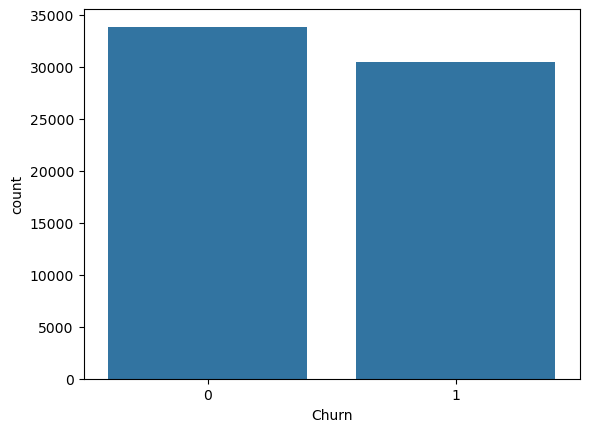

In [22]:
sns.countplot(x='Churn',data=df)
plt.show()

In [24]:
df['MonthlyCharges'] = df['Total Spend']/df['Contract Length']

In [25]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,MonthlyCharges
0,1,22,0,25,14,4,27,1,1,598,9,1,598.000000
1,2,41,0,28,28,7,13,2,1,584,20,0,584.000000
2,3,47,1,27,10,2,29,3,12,757,21,0,63.083333
3,4,35,1,9,12,5,17,3,3,232,18,0,77.333333
4,5,53,0,58,24,9,2,2,12,533,18,0,44.416667


<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

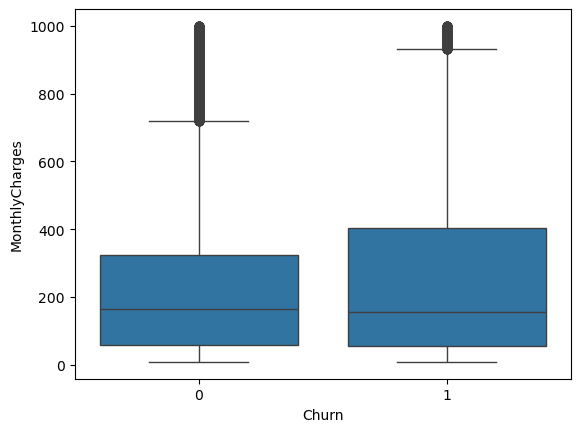

In [26]:
sns.boxplot(x='Churn',y='MonthlyCharges',data=df)

<Axes: xlabel='Churn', ylabel='Tenure'>

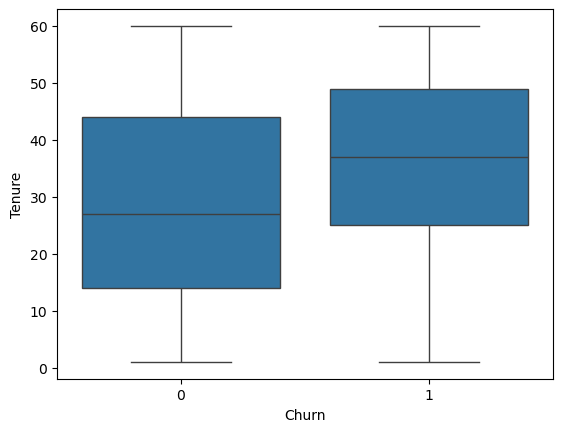

In [27]:
sns.boxplot(x='Churn',y='Tenure',data=df)

In [28]:
df = df.drop(['CustomerID'], axis=1)

In [30]:
df['MonthlyCharges'] = df['MonthlyCharges'].round(2)

In [31]:
df.to_csv('CustomerChurnDataset\processed.csv')